### Task 1: Environment Setup, Image I/O & Morphological Operations

1.1
Environment setup & image loading

In [36]:
# %pip install opencv-python
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("OpenCV Version:", cv2.__version__)

OpenCV Version: 5.0.0


Grayscale Image
Shape: (413, 550)
Data Type: uint8

Color Image
Shape: (425, 540, 3)
Data Type: uint8


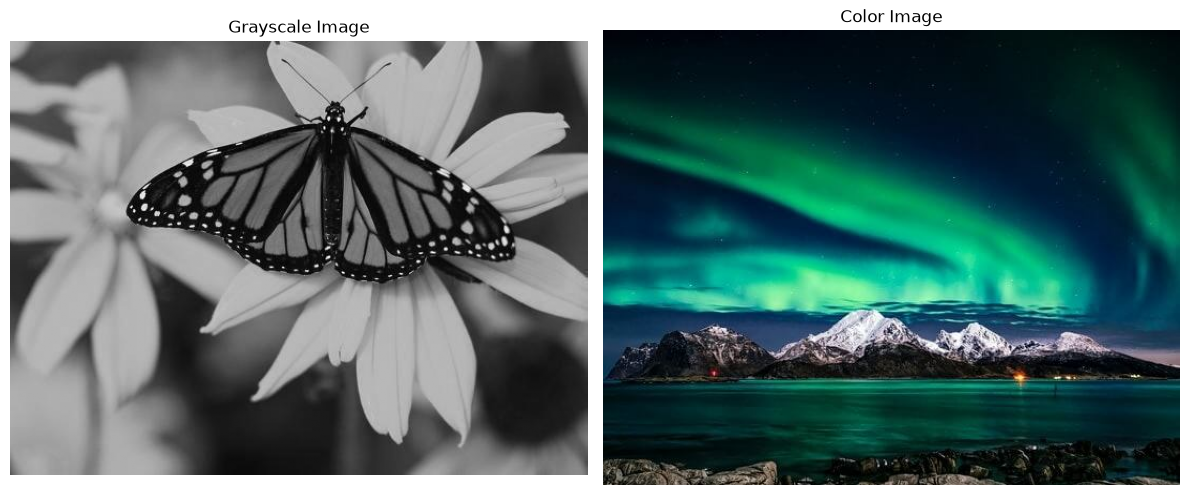

In [37]:
gray_path = "grayscale.jpg"
color_path = "aurora-borealis.jpg"
gray_img = cv2.imread(gray_path, cv2.IMREAD_GRAYSCALE)
color_img = cv2.imread(color_path, cv2.IMREAD_COLOR)

print("Grayscale Image")
print("Shape:", gray_img.shape)
print("Data Type:", gray_img.dtype)

print("\nColor Image")
print("Shape:", color_img.shape)
print("Data Type:", color_img.dtype)

color_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(color_rgb)
plt.title("Color Image")
plt.axis("off")

plt.tight_layout()
plt.show()

1.2
Binarize a test image

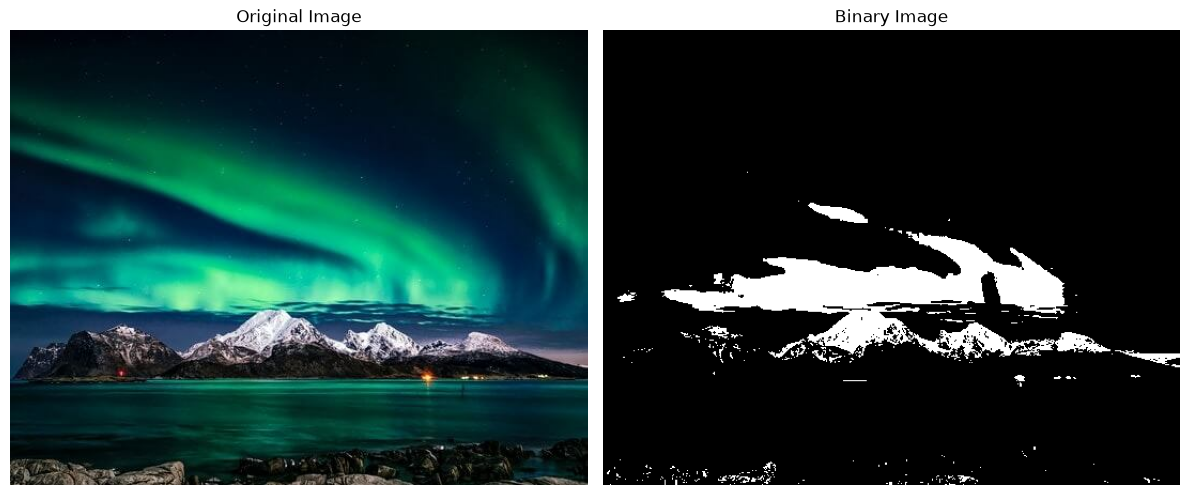

In [38]:
img = cv2.imread("aurora-borealis.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.show()

1.3
Apply the four morphological operations

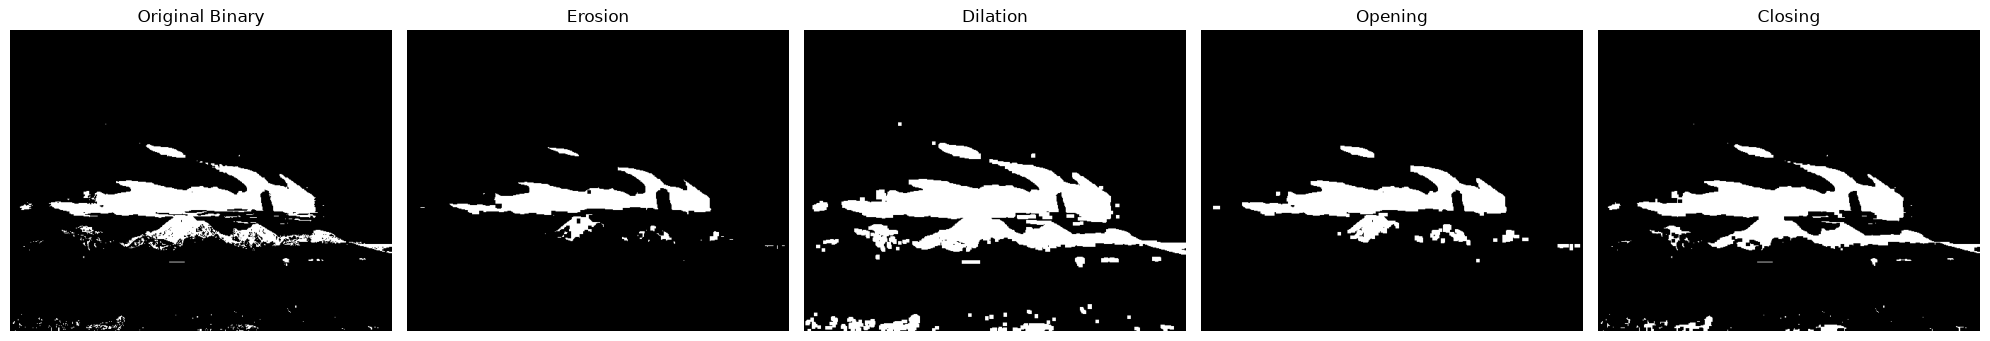

In [39]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(binary, kernel)
dilation = cv2.dilate(binary, kernel)
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)
closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(binary, cmap="gray")
plt.title("Original Binary")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

1.4
Kernel shape & size comparison

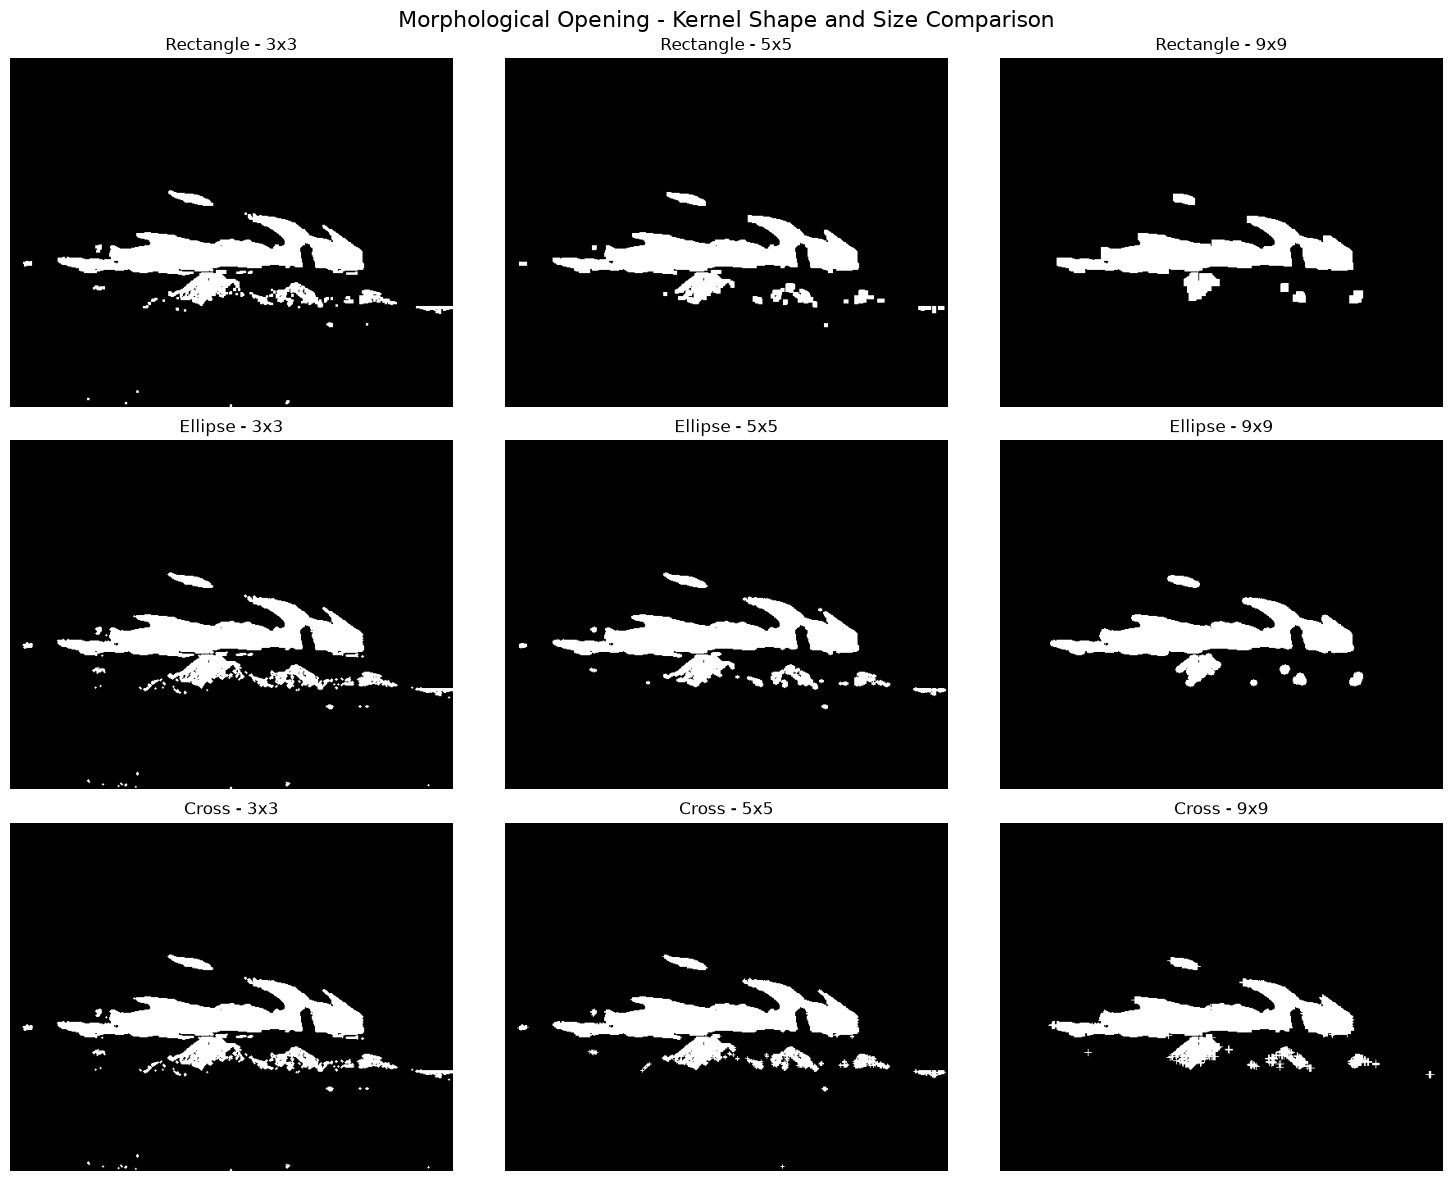

In [40]:
shapes = {
    "Rectangle": cv2.MORPH_RECT,
    "Ellipse": cv2.MORPH_ELLIPSE,
    "Cross": cv2.MORPH_CROSS
}
sizes = [3, 5, 9]
plt.figure(figsize=(15, 12))

plot_number = 1

for shape_name, shape_type in shapes.items():

    for size in sizes:

        kernel_shape = cv2.getStructuringElement(
            shape_type,
            (size, size)
        )

        result = cv2.morphologyEx(
            binary,
            cv2.MORPH_OPEN,
            kernel_shape
        )

        plt.subplot(3, 3, plot_number)
        plt.imshow(result, cmap="gray")
        plt.title(f"{shape_name} - {size}x{size}")
        plt.axis("off")

        plot_number += 1

plt.suptitle("Morphological Opening - Kernel Shape and Size Comparison",fontsize=16)
plt.tight_layout()
plt.show()

### Task 2: Bitwise Operations & Image Histograms

2.1
Bitwise AND / OR / XOR / NOT

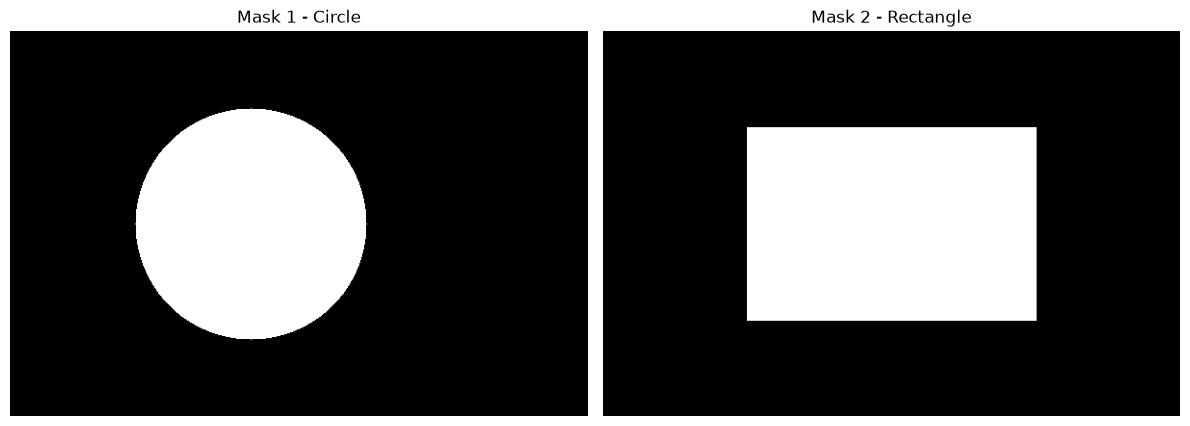

In [41]:
mask1 = np.zeros((400, 600), dtype=np.uint8)
mask2 = np.zeros((400, 600), dtype=np.uint8)

cv2.circle(
    mask1,center=(250, 200),radius=120,color=255,thickness=-1
)
cv2.rectangle(mask2,pt1=(150, 100),pt2=(450, 300),color=255,thickness=-1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask 1 - Circle")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask 2 - Rectangle")
plt.axis("off")

plt.tight_layout()
plt.show()

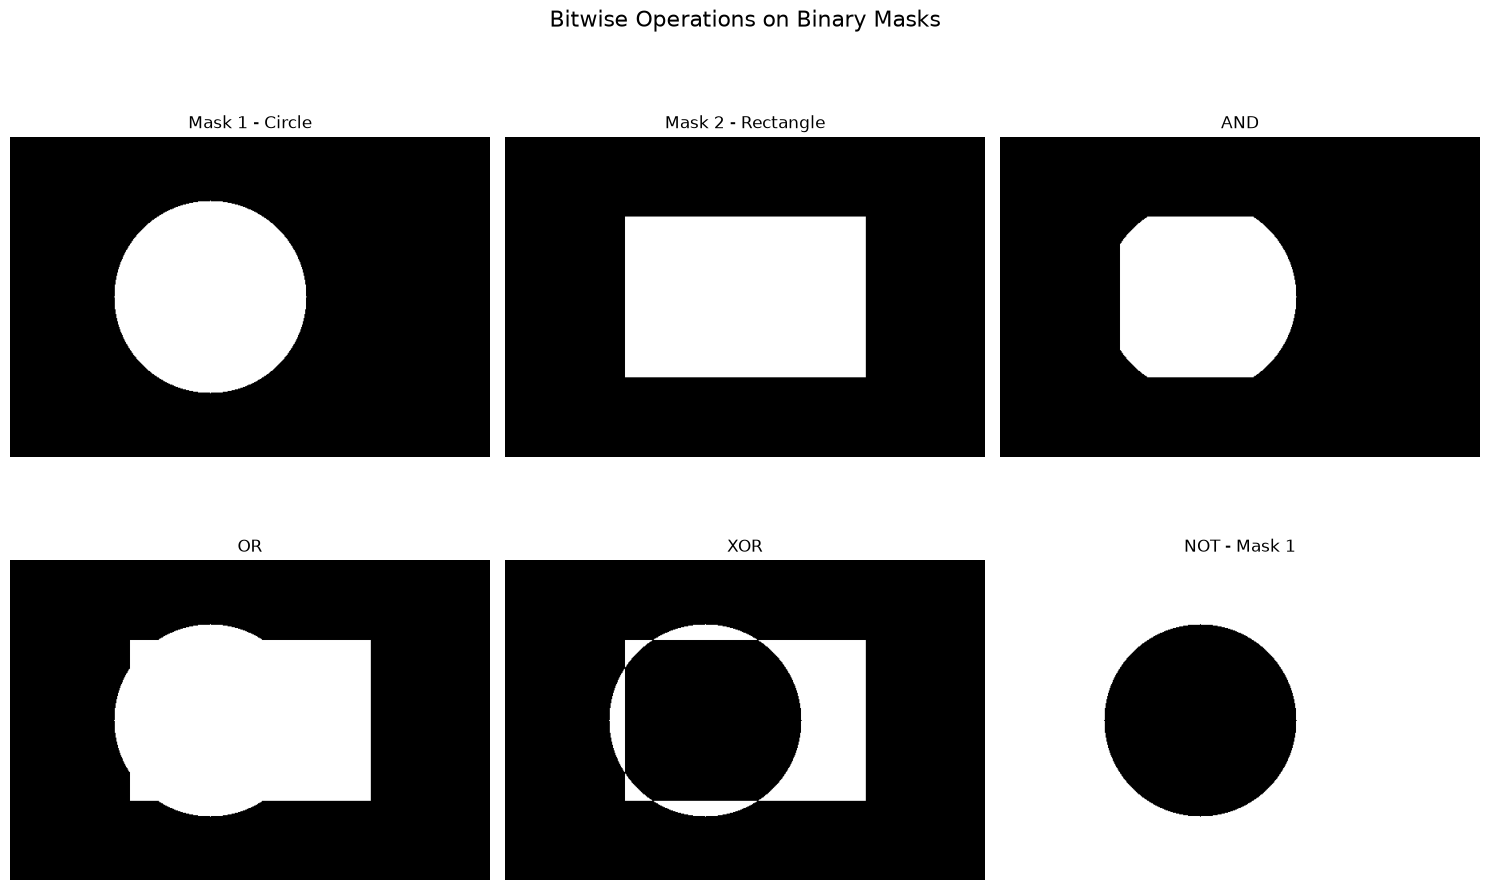

In [42]:
bitwise_and = cv2.bitwise_and(mask1, mask2)
bitwise_or = cv2.bitwise_or(mask1, mask2)
bitwise_xor = cv2.bitwise_xor(mask1, mask2)
bitwise_not = cv2.bitwise_not(mask1)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask 1 - Circle")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask 2 - Rectangle")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(bitwise_and, cmap="gray")
plt.title("AND")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bitwise_or, cmap="gray")
plt.title("OR")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(bitwise_xor, cmap="gray")
plt.title("XOR")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(bitwise_not, cmap="gray")
plt.title("NOT - Mask 1")
plt.axis("off")

plt.suptitle(
    "Bitwise Operations on Binary Masks",
    fontsize=16
)

plt.tight_layout()
plt.show()

2.2
Applied use-case: masked overlay

Image Shape: (408, 612, 3)


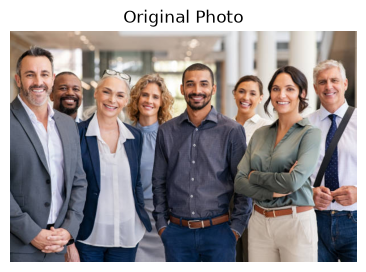

In [107]:
photo = cv2.imread("people.jpg")
photo_rgb = cv2.cvtColor(photo, cv2.COLOR_BGR2RGB)

print("Image Shape:", photo.shape)

plt.figure(figsize=(5,3))
plt.imshow(photo_rgb)
plt.title("Original Photo")
plt.axis("off")
plt.show()

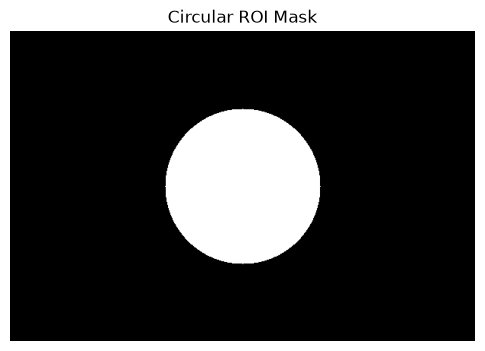

In [44]:
roi_mask = np.zeros(photo.shape[:2], dtype=np.uint8)
height, width = roi_mask.shape
center = (width // 2, height // 2)
radius = min(width, height) // 4
cv2.circle(
    roi_mask,
    center,
    radius,
    255,
    -1
)

plt.figure(figsize=(6, 5))
plt.imshow(roi_mask, cmap="gray")
plt.title("Circular ROI Mask")
plt.axis("off")
plt.show()

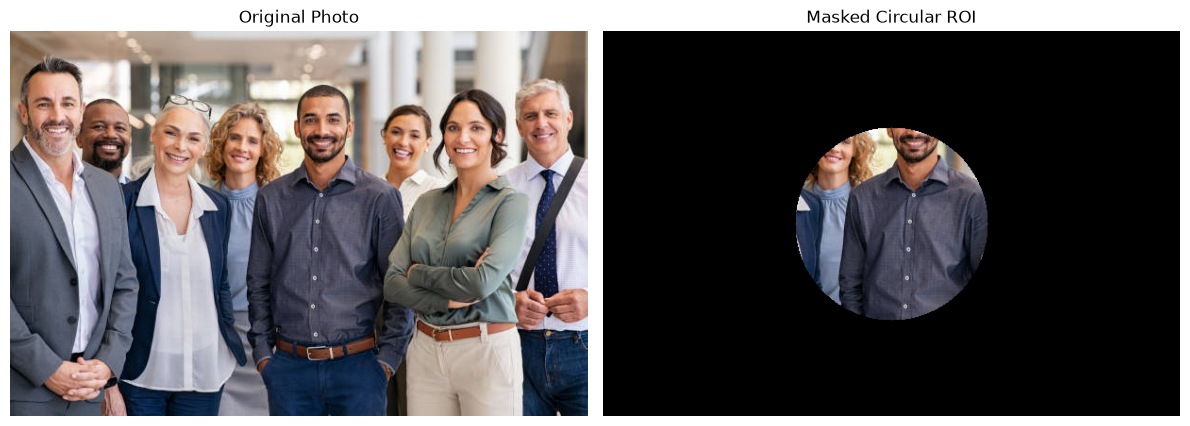

In [45]:
masked_region = cv2.bitwise_and(
    photo,
    photo,
    mask=roi_mask
)

masked_region_rgb = cv2.cvtColor(
    masked_region,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(photo_rgb)
plt.title("Original Photo")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masked_region_rgb)
plt.title("Masked Circular ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
cv2.bitwise_and(photo, photo, mask=roi_mask)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(408, 612, 3), dtype=uint8)

2.3
Grayscale & per-channel colour histograms

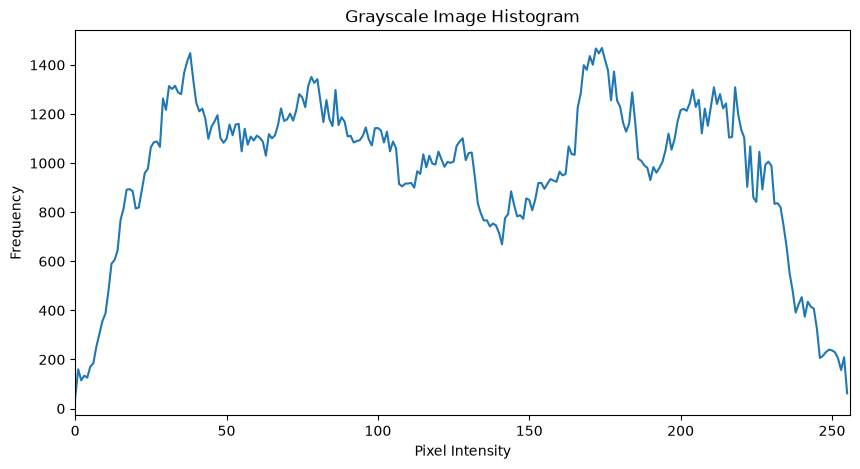

In [47]:
gray_photo = cv2.cvtColor(photo,cv2.COLOR_BGR2GRAY)

gray_hist = cv2.calcHist(
    [gray_photo],
    [0],
    None,
    [256],
    [0, 256]
)
plt.figure(figsize=(10, 5))

plt.plot(gray_hist)
plt.title("Grayscale Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.show()

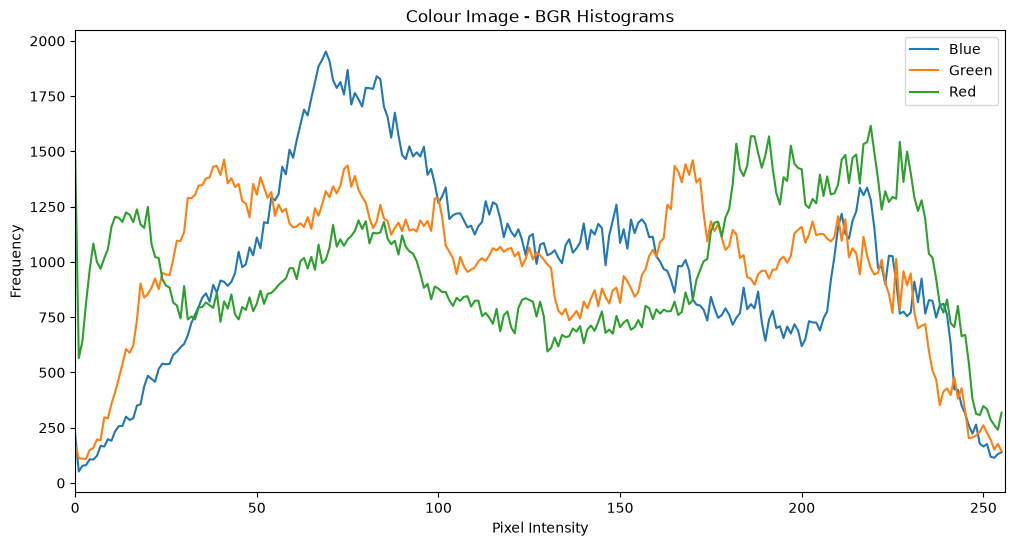

In [48]:
blue_hist = cv2.calcHist([photo],[0],None,[256],[0, 256])
green_hist = cv2.calcHist([photo],[1],None,[256],[0, 256])
red_hist = cv2.calcHist([photo],[2],None,[256],[0, 256])

plt.figure(figsize=(12, 6))

plt.plot(blue_hist, label="Blue")
plt.plot(green_hist, label="Green")
plt.plot(red_hist, label="Red")

plt.title("Colour Image - BGR Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.show()

2.4
Brightness & contrast adjustment

In [49]:
bright_image = cv2.convertScaleAbs(photo,alpha=1.5,beta=30)
dark_image = cv2.convertScaleAbs(photo,alpha=0.7,beta=-30)

In [50]:
original_gray = cv2.cvtColor(
    photo,
    cv2.COLOR_BGR2GRAY
)

bright_gray = cv2.cvtColor(
    bright_image,
    cv2.COLOR_BGR2GRAY
)

dark_gray = cv2.cvtColor(
    dark_image,
    cv2.COLOR_BGR2GRAY
)

original_hist = cv2.calcHist([original_gray],[0],None,[256],[0, 256])
bright_hist = cv2.calcHist([bright_gray],[0],None,[256],[0, 256])
dark_hist = cv2.calcHist([dark_gray],[0],None,[256],[0, 256])

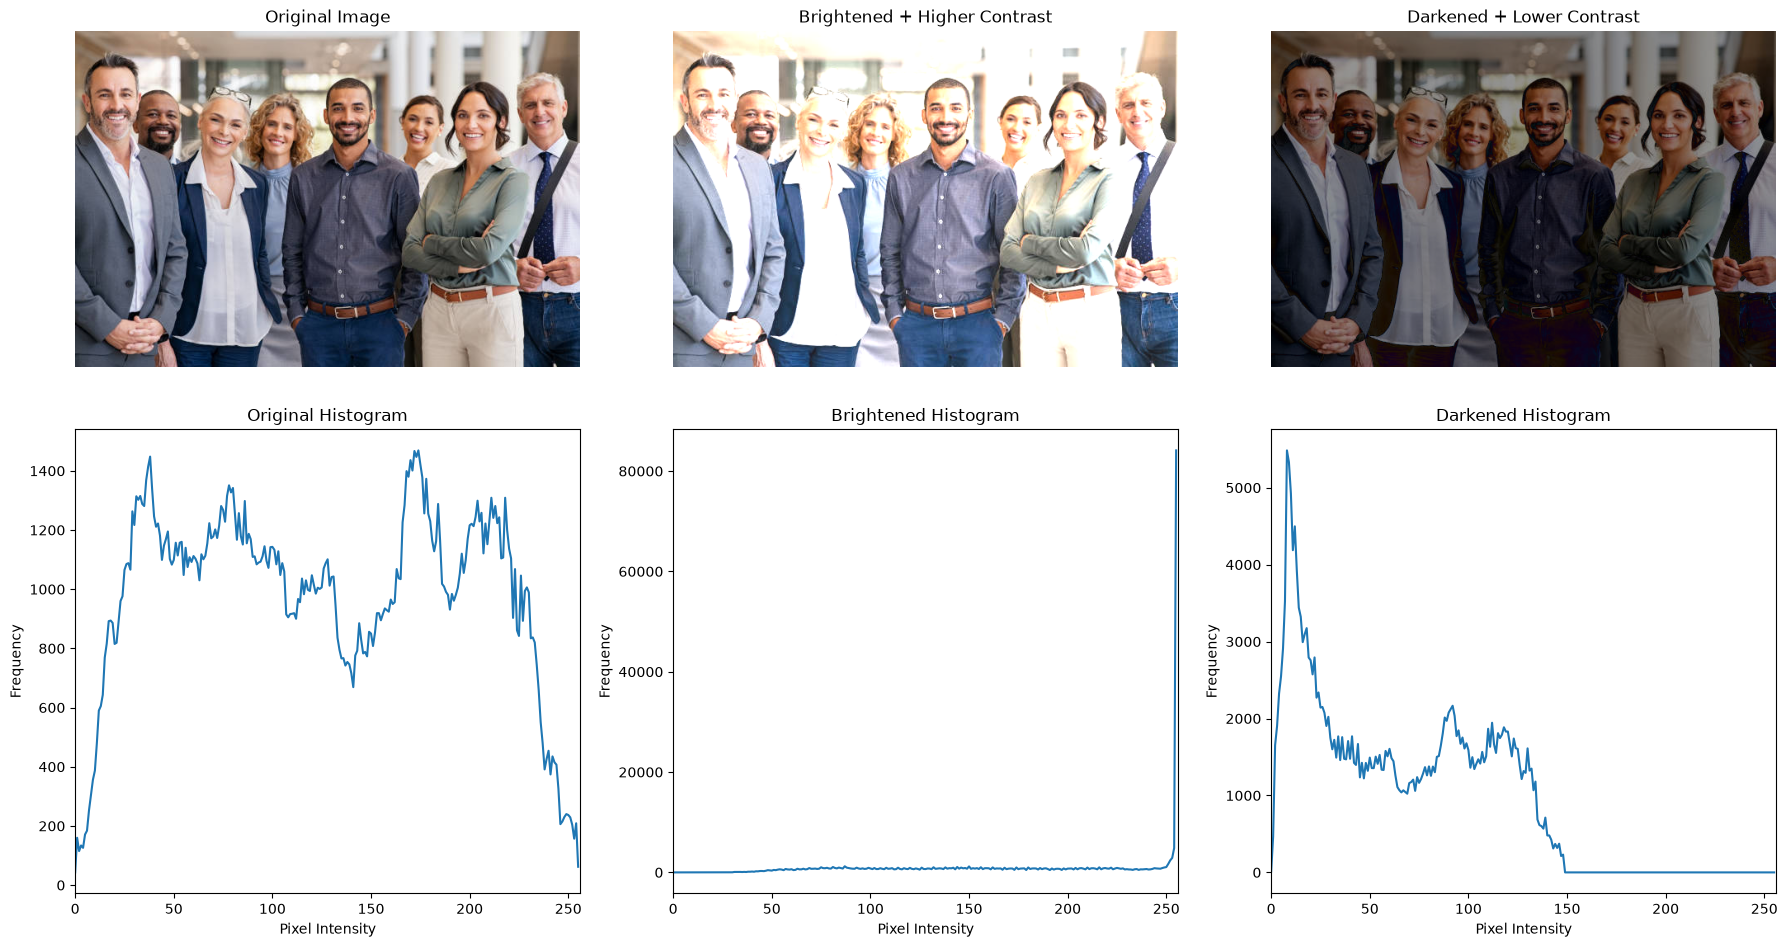

In [51]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.plot(original_hist)
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(bright_image, cv2.COLOR_BGR2RGB))
plt.title("Brightened + Higher Contrast")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.plot(bright_hist)
plt.title("Brightened Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(dark_image, cv2.COLOR_BGR2RGB))
plt.title("Darkened + Lower Contrast")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.plot(dark_hist)
plt.title("Darkened Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])


plt.tight_layout()
plt.show()

### Task 3: Face Detection with YuNet (OpenCV 5.0)

3.1
Load the YuNet face detector

Image Width : 612
Image Height: 408
YuNet face detector loaded successfully.
Number of faces detected: 8
Detection array shape: (8, 15)


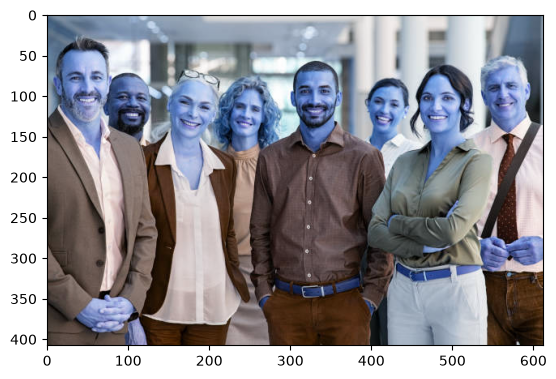

In [52]:
model_path = "face_detection_yunet_2023mar.onnx"

img = cv2.imread("people.jpg")
img_h, img_w = img.shape[:2]

print("Image Width :", img_w)
print("Image Height:", img_h)

detector = cv2.FaceDetectorYN.create(
    model_path,
    "",
    (img_w, img_h),
    0.9
)

print("YuNet face detector loaded successfully.")

detector.setInputSize((img_w, img_h))
_, faces = detector.detect(img)

plt.imshow(img)
print("Number of faces detected:", len(faces))
print("Detection array shape:", faces.shape)

3.2
Detect on static images

In [53]:
def draw_yunet_detections(image, faces):

    output = image.copy()

    if faces is None:
        return output

    for face in faces:

        x, y, w, h = face[:4].astype(int)
        score = face[14]
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        landmarks = face[4:14].reshape(5, 2).astype(int)

        for px, py in landmarks:
            cv2.circle(
                output,
                (px, py),
                3,
                (0, 0, 255),
                -1
            )

        cv2.putText(
            output,
            f"Face: {score:.2f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return output

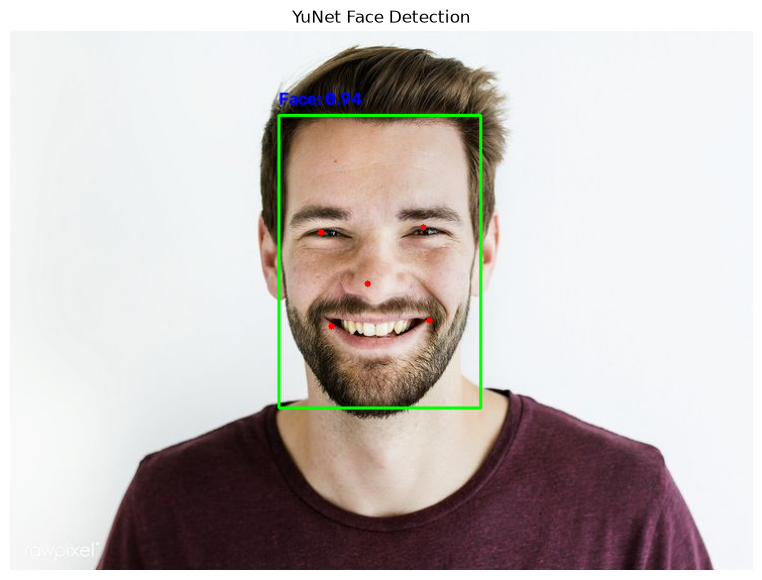

In [54]:
img = cv2.imread("front.jpg")

img_h, img_w = img.shape[:2]
detector.setInputSize((img_w, img_h))
_, faces = detector.detect(img)
result = draw_yunet_detections(img, faces)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 7))
plt.imshow(result_rgb)
plt.title("YuNet Face Detection")
plt.axis("off")
plt.show()

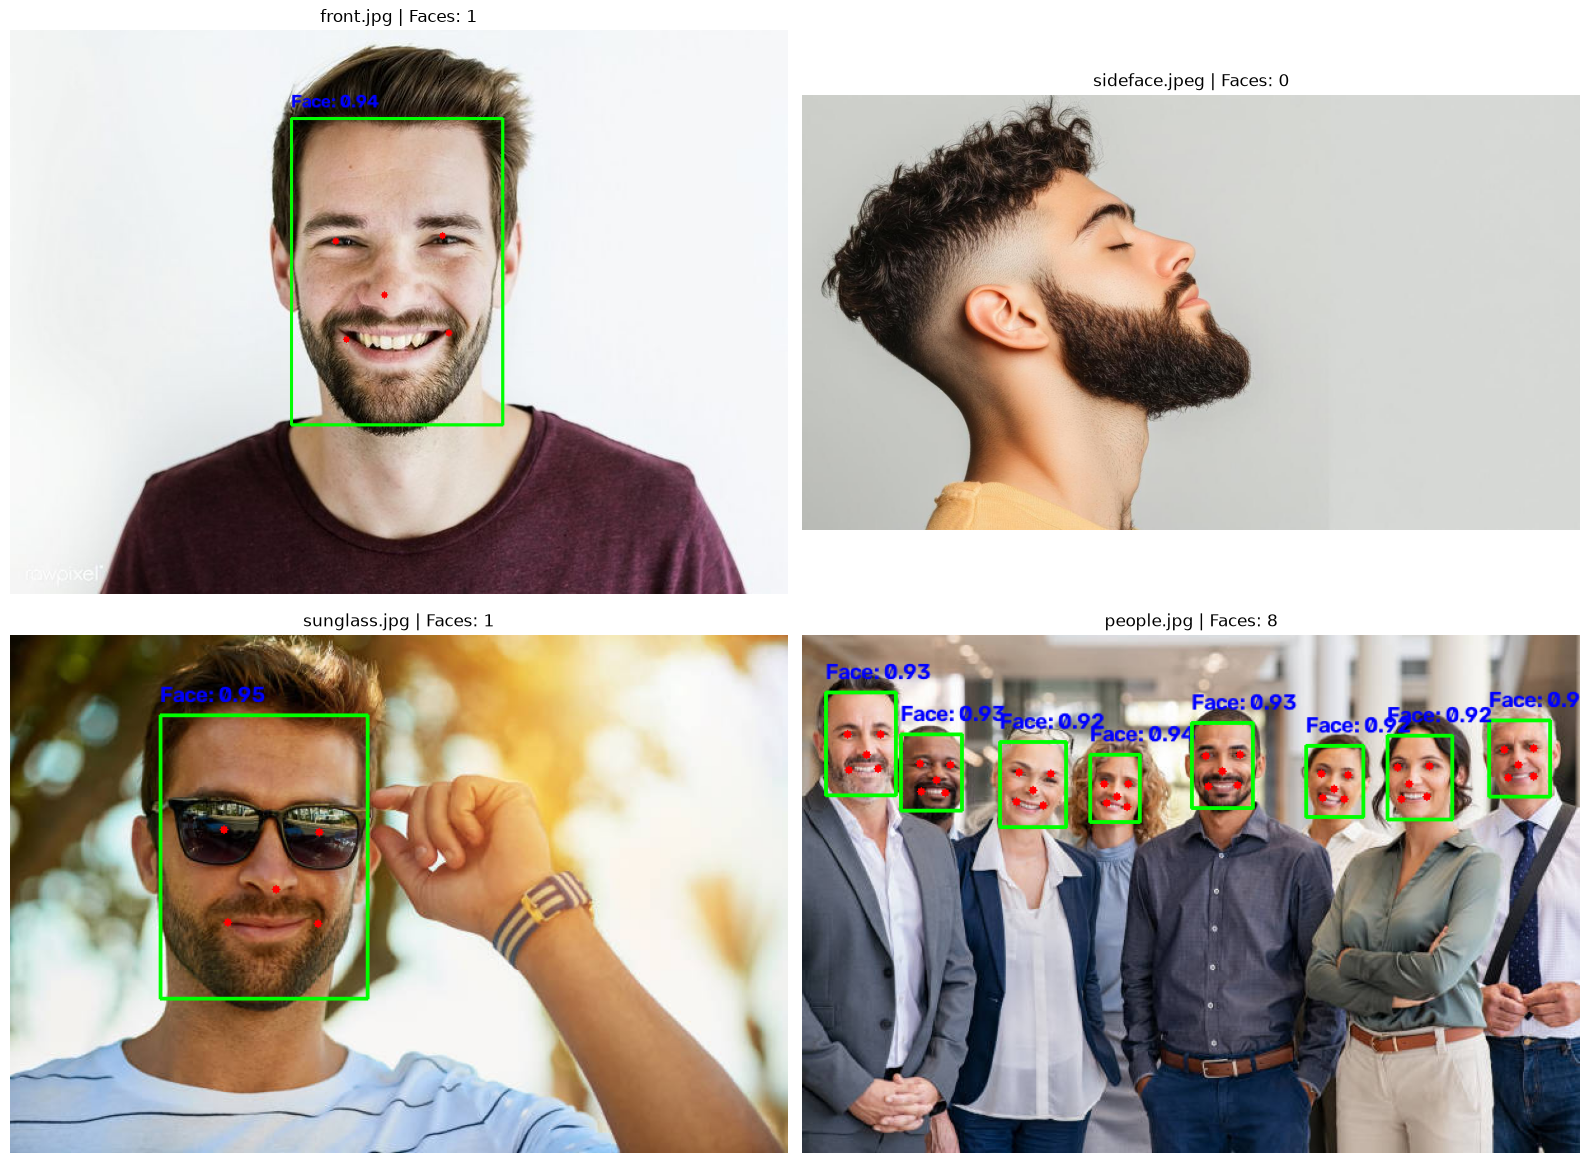

In [55]:
face_images = [
    "front.jpg",
    "sideface.jpeg",
    "sunglass.jpg",
    "people.jpg"
]

plt.figure(figsize=(16, 12))

for i, image_path in enumerate(face_images):

    img = cv2.imread(image_path)
    img_h, img_w = img.shape[:2]

    detector.setInputSize((img_w, img_h))
    _, faces = detector.detect(img)
    result = draw_yunet_detections(img, faces)

    result_rgb = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(result_rgb)
    plt.title(
        f"{image_path} | Faces: "
        f"{0 if faces is None else len(faces)}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

3.3
Real-time detection on webcam

In [ ]:
import time
import cv2

cap = cv2.VideoCapture(0)
previous_size = None

frame_count = 0
start_time = time.time()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Could not read frame.")
        break

    h, w = frame.shape[:2]
    current_size = (w, h)

    if current_size != previous_size:
        detector.setInputSize(current_size)
        previous_size = current_size

    _, faces = detector.detect(frame)
    frame = draw_yunet_detections(frame, faces)
    frame_count += 1
    elapsed = time.time() - start_time

    if elapsed > 0:
        fps = frame_count / elapsed
    else:
        fps = 0

    cv2.putText(
        frame,
        f"FPS: {fps:.2f}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    cv2.imshow("YuNet Real-Time Face Detection", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == 27:
        break

cap.release()
cv2.destroyAllWindows()

print('Q or Esc for exit')
print(f"Average FPS: {fps:.2f}")

3.4
Score-threshold experiment & applied privacy use-case

In [57]:
def detect_with_threshold(image, threshold):

    h, w = image.shape[:2]
    temp_detector = cv2.FaceDetectorYN.create(
        model_path,
        "",
        (w, h),
        threshold
    )

    temp_detector.setInputSize((w, h))
    _, faces = temp_detector.detect(image)

    return faces

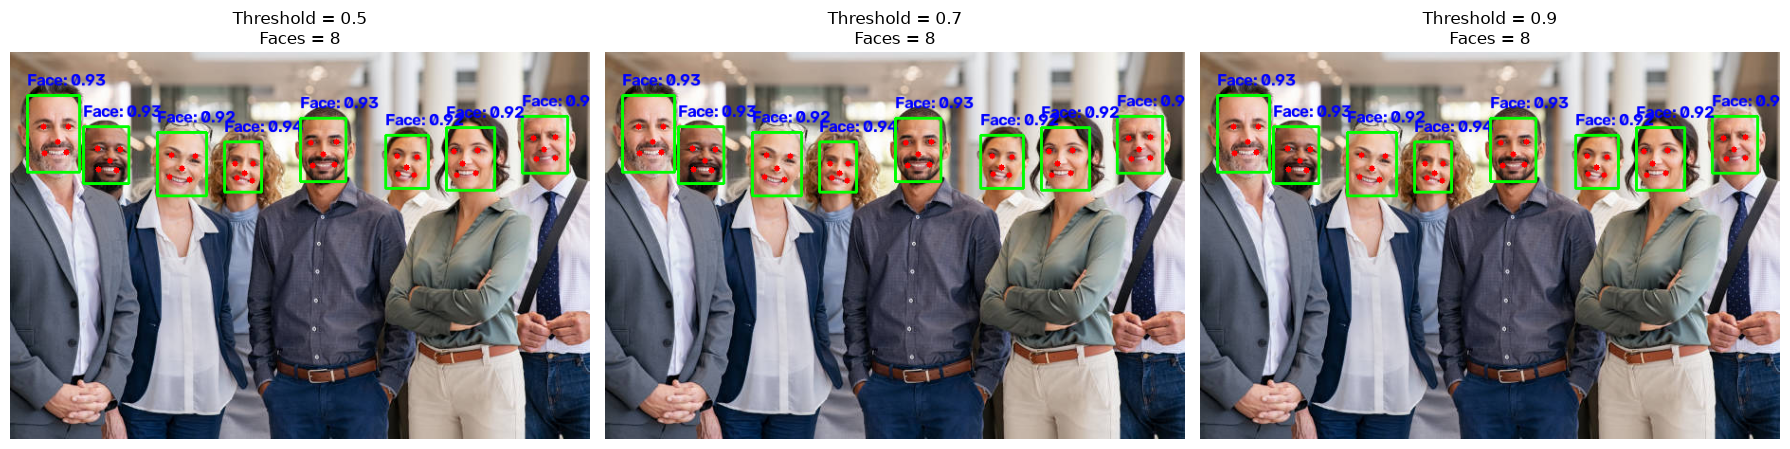

In [58]:
test_img = cv2.imread("people.jpg")

thresholds = [0.5, 0.7, 0.9]
plt.figure(figsize=(18, 6))

for i, threshold in enumerate(thresholds):

    faces = detect_with_threshold(test_img,threshold)
    result = draw_yunet_detections(test_img,faces)
    result_rgb = cv2.cvtColor(result,cv2.COLOR_BGR2RGB)

    count = 0 if faces is None else len(faces)

    plt.subplot(1, 3, i + 1)
    plt.imshow(result_rgb)
    plt.title(
        f"Threshold = {threshold}\n"
        f"Faces = {count}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
def blur_detected_faces(image, faces):
    output = image.copy()

    for face in faces:

        x, y, w, h = face[:4].astype(int)

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(output.shape[1], x + w)
        y2 = min(output.shape[0], y + h)

        face_roi = output[y1:y2, x1:x2]

        if face_roi.size == 0:
            continue

        blurred_roi = cv2.GaussianBlur(
            face_roi,
            (51, 51),
            0
        )

        output[y1:y2, x1:x2] = blurred_roi
    return output

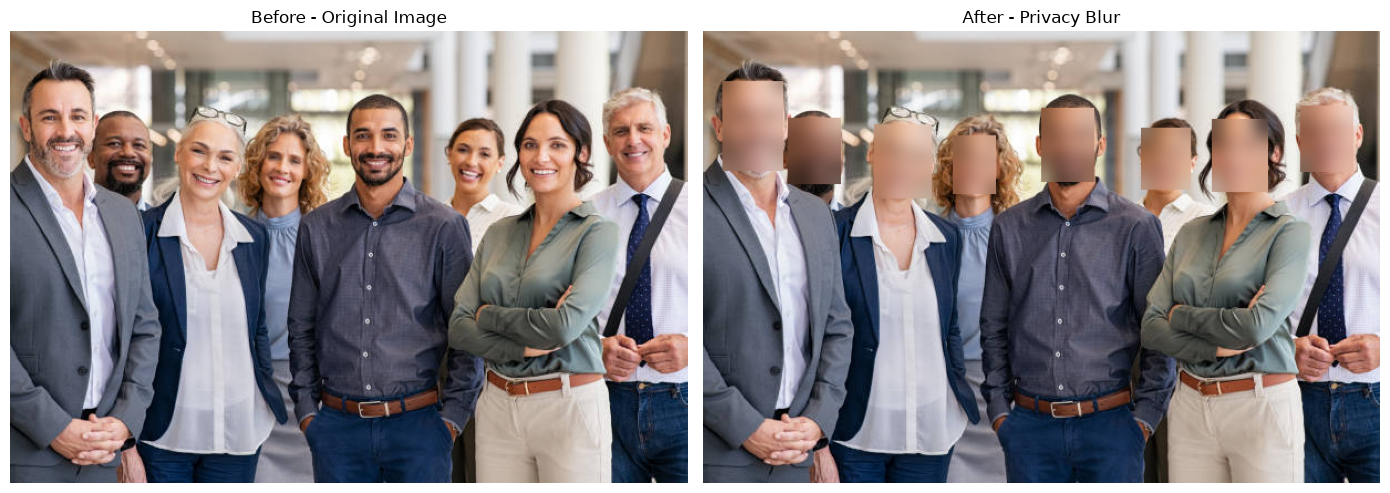

In [60]:
privacy_img = cv2.imread("people.jpg")

faces = detect_with_threshold(
    privacy_img,
    0.9
)

blurred_img = blur_detected_faces(
    privacy_img,
    faces
)

privacy_rgb = cv2.cvtColor(
    privacy_img,
    cv2.COLOR_BGR2RGB
)

blurred_rgb = cv2.cvtColor(
    blurred_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(privacy_rgb)
plt.title("Before - Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_rgb)
plt.title("After - Privacy Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 4: Object Detection with YOLO
4.1
Load pretrained YOLOv8 & run on static images

In [61]:
from ultralytics import YOLO
import time

from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully.")

YOLOv8 model loaded successfully.



image 1/1 d:\Aditya D\Deep L\pr 3\dog.jpg: 480x640 1 dog, 110.7ms
Speed: 8.9ms preprocess, 110.7ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Aditya D\Deep L\pr 3\chair.jpg: 480x640 1 chair, 87.6ms
Speed: 3.9ms preprocess, 87.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Aditya D\Deep L\pr 3\car.jpg: 384x640 1 car, 70.3ms
Speed: 2.7ms preprocess, 70.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


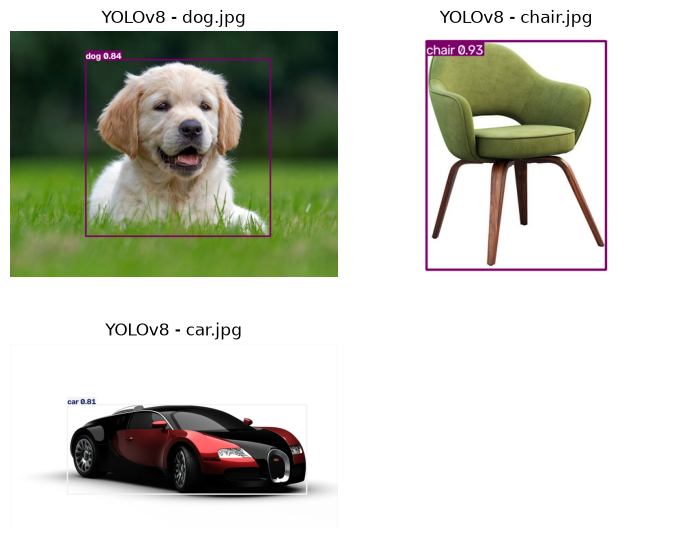

In [62]:
yolo_images = [
    'dog.jpg',
    'chair.jpg',
    'car.jpg'
]

plt.figure(figsize=(7,6))

for i, image_name in enumerate(yolo_images):

    image_path = image_name
    results = model(image_path)
    annotated_image = results[0].plot()

    annotated_rgb = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )
    plt.subplot(2, 2, i + 1)
    plt.imshow(annotated_rgb)
    plt.title(f"YOLOv8 - {image_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

4.2
Real-time YOLO on webcam

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

frame_count = 0
start_time = time.time()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Could not read frame.")
        break

    results = model(
        frame,
        verbose=False
    )

    annotated_frame = results[0].plot()
    frame_count += 1
    elapsed = time.time() - start_time

    if elapsed > 0:
        fps = frame_count / elapsed
    else:
        fps = 0

    cv2.putText(
        annotated_frame,
        f"FPS: {fps:.2f}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    cv2.imshow(
        "YOLOv8 Real-Time Object Detection",
        annotated_frame
    )
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print('Q or Esc for exit')
print(f"Achieved FPS: {fps:.2f}")

4.3
Confidence & IoU threshold tuning

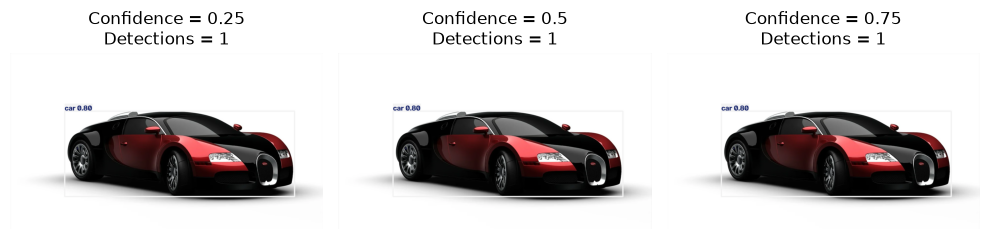

In [73]:
test_image = ['car.jpg','chair.jpg','dog.jpg','people.jpg']
confidence_values = [0.25, 0.5, 0.75]

plt.figure(figsize=(10,8))

for i, conf in enumerate(confidence_values):

    results = model(
        test_image,
        conf=conf,
        verbose=False
    )

    annotated_image = results[0].plot()
    annotated_rgb = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    boxes = results[0].boxes

    if boxes is not None:
        detection_count = len(boxes)
    else:
        detection_count = 0
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(annotated_rgb)
    plt.title(
        f"Confidence = {conf}\n"
        f"Detections = {detection_count}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

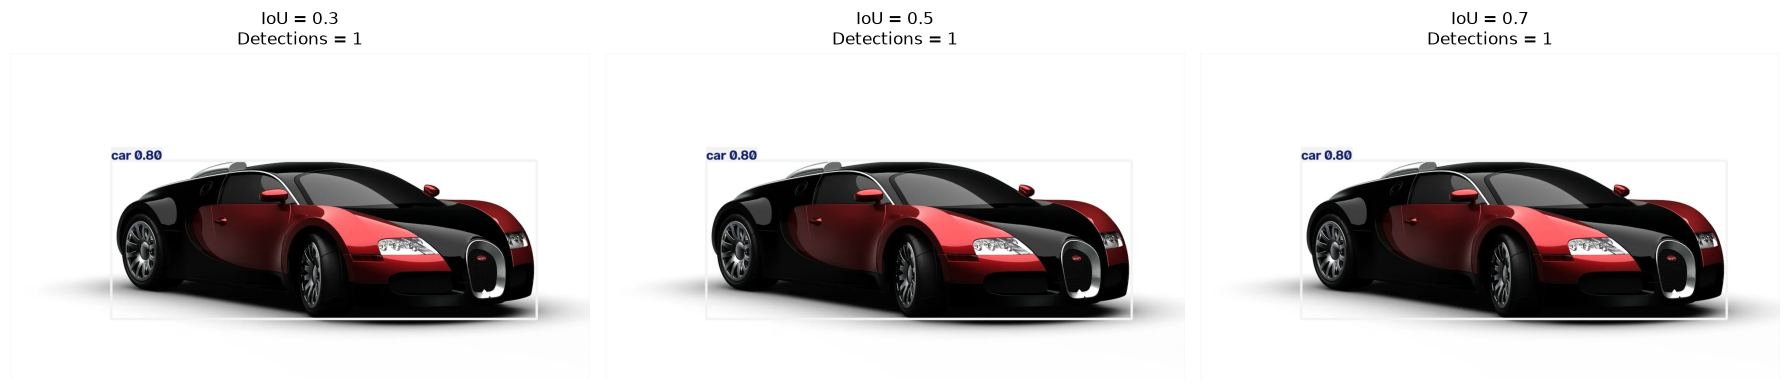

In [74]:
iou_values = [0.3, 0.5, 0.7]

plt.figure(figsize=(18, 6))

for i, iou in enumerate(iou_values):

    results = model(
        test_image,
        conf=0.25,
        iou=iou,
        verbose=False
    )

    annotated_image = results[0].plot()

    annotated_rgb = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    boxes = results[0].boxes

    if boxes is not None:
        detection_count = len(boxes)
    else:
        detection_count = 0

    plt.subplot(1, 3, i + 1)
    plt.imshow(annotated_rgb)
    plt.title(
        f"IoU = {iou}\n"
        f"Detections = {detection_count}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

4.4
Per-class detection summary

In [68]:
from collections import Counter
results = model(
    test_image,
    verbose=False
)

class_counts = Counter()

if results[0].boxes is not None:

    class_ids = results[0].boxes.cls.cpu().numpy().astype(int)

    for class_id in class_ids:
        class_name = model.names[class_id]
        class_counts[class_name] += 1

print("Detection Summary:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Detection Summary:
car: 1


In [77]:
total_class_counts = Counter()

for image_name in yolo_images:

    image_path =  image_name
    results = model(
        image_path,
        verbose=False
    )

    if results[0].boxes is None:
        continue

    class_ids = (results[0].boxes.cls.cpu().numpy().astype(int))
    for class_id in class_ids:
        class_name = model.names[class_id]
        total_class_counts[class_name] += 1

print("Total Detection Summary")

for class_name, count in total_class_counts.items():
    print(f"{class_name}: {count}")

Total Detection Summary
dog: 1
chair: 1
car: 1


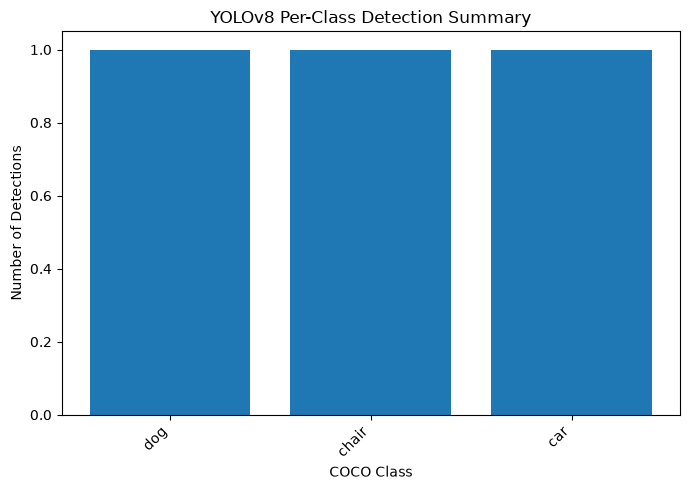

In [ ]:
classes = list(total_class_counts.keys())
counts = list(total_class_counts.values())

plt.figure(figsize=(7,5))

plt.bar(classes, counts)

plt.title("YOLOv8 Per-Class Detection Summary")
plt.xlabel("COCO Class")
plt.ylabel("Number of Detections")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

### Task 5: Integrated Pipeline & Final Comparison

5.1
Build the unified pipeline

In [86]:
def draw_yunet_green(image, faces):

    output = image.copy()

    if faces is None:
        return output

    for face in faces:

        x, y, w, h = face[:4].astype(int)

        score = face[14]
        cv2.rectangle(output,(x, y),(x + w, y + h),(0, 255, 0),2)
        landmarks = face[4:14].reshape(5, 2).astype(int)

        for px, py in landmarks:
            cv2.circle(output,(px, py),3,(0, 255, 0),-1)

        cv2.putText(output,f"Face {score:.2f}",(x, max(y - 10, 20)),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0, 255, 0),2)
    return output

results[0].plot()

array([[[226, 226, 226],
        [234, 234, 234],
        [236, 236, 236],
        ...,
        [236, 236, 236],
        [234, 234, 234],
        [228, 228, 228]],

       [[247, 247, 247],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [249, 249, 249]],

       [[246, 246, 246],
        [253, 253, 253],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [254, 254, 254],
        [248, 248, 248]],

       ...,

       [[246, 246, 246],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [255, 255, 255],
        [246, 246, 246]],

       [[246, 246, 246],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [255, 255, 255],
        [246, 246, 246]],

       [[246, 246, 246],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [255, 255, 255],
        [246, 246, 246]]

In [ ]:
def draw_yolo_red(image, results):

    output = image.copy()
    boxes = results[0].boxes

    if boxes is None:
        return output

    for box in boxes:

        x1, y1, x2, y2 = (box.xyxy[0].cpu().numpy().astype(int))

        confidence = float(box.conf[0].cpu().numpy())
        class_id = int(box.cls[0].cpu().numpy())
        class_name = model.names[class_id]

        cv2.rectangle(output,(x1, y1),(x2, y2),(0, 0, 255),2)
        label = f"{class_name} {confidence:.2f}"

        cv2.putText(output,label,(x1, max(y1 - 10, 20)),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0, 0, 255),2)

    return output

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

previous_size = None

frame_count = 0
start_time = time.time()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam frame.")
        break

    h, w = frame.shape[:2]
    current_size = (w, h)

    if current_size != previous_size:

        detector.setInputSize(current_size)
        previous_size = current_size

    _, faces = detector.detect(frame)

    output = draw_yunet_green(
        frame,
        faces
    )
    yolo_results = model(frame,verbose=False)
    output = draw_yolo_red(output,yolo_results)

    frame_count += 1
    elapsed = time.time() - start_time

    if elapsed > 0:
        fps = frame_count / elapsed
    else:
        fps = 0

    cv2.putText(output,f"FPS: {fps:.2f}",(20, 35),cv2.FONT_HERSHEY_SIMPLEX,1,(255, 255, 0),2)
    cv2.putText(output,"Green = YuNet | Red = YOLO",(20, 70),cv2.FONT_HERSHEY_SIMPLEX,0.7,(255, 255, 0),2)
    cv2.imshow("Integrated YuNet + YOLO Pipeline",output)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"Combined Pipeline FPS: {fps:.2f}")

Combined Pipeline FPS: 5.95


5.2
Morphological pre-cleaning

In [87]:
def morphological_opening(frame):

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    _, binary = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    opened = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    return opened

5.3
FPS benchmarking

In [92]:
def benchmark_yunet(num_frames=100):

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Could not open webcam.")

    frame_count = 0
    start_time = time.time()

    while frame_count < num_frames:

        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]
        detector.setInputSize(
            (w, h)
        )
        detector.detect(frame)

        frame_count += 1

    elapsed = time.time() - start_time
    cap.release()
    fps = frame_count / elapsed
    return fps

yunet_fps = benchmark_yunet(100)
print(f"YuNet Average FPS: {yunet_fps:.2f}")

YuNet Average FPS: 12.93


In [96]:
def benchmark_yolo(num_frames=100):

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        raise RuntimeError("Could not open webcam.")

    frame_count = 0
    start_time = time.time()

    while frame_count < num_frames:

        ret, frame = cap.read()
        if not ret:
            break

        model(frame,verbose=False)
        frame_count += 1

    elapsed = time.time() - start_time
    cap.release()
    fps = frame_count / elapsed
    return fps

yolo_fps = benchmark_yolo(100)
print(f"YOLO Average FPS: {yolo_fps:.2f}")

YOLO Average FPS: 10.37


In [94]:
def benchmark_combined(num_frames=100):

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Could not open webcam.")

    frame_count = 0
    start_time = time.time()
    previous_size = None

    while frame_count < num_frames:

        ret, frame = cap.read()

        if not ret:
            break

        h, w = frame.shape[:2]
        current_size = (w, h)
        if current_size != previous_size:

            detector.setInputSize(current_size)
            previous_size = current_size

        detector.detect(frame)
        model(frame,verbose=False)
        frame_count += 1

    elapsed = time.time() - start_time
    cap.release()
    fps = frame_count / elapsed
    return fps

In [95]:
combined_fps = benchmark_combined(100)
print(f"Combined Pipeline FPS: {combined_fps:.2f}")

Combined Pipeline FPS: 6.14


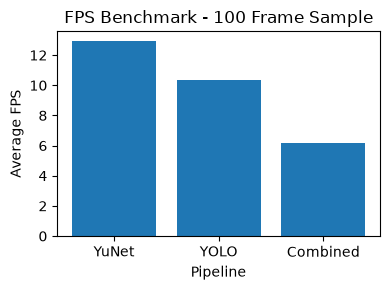

In [102]:
fps_names = ["YuNet","YOLO","Combined"]
fps_values = [yunet_fps,yolo_fps,combined_fps]
plt.figure(figsize=(4,3))
plt.bar(fps_names,fps_values)
plt.title("FPS Benchmark - 100 Frame Sample")
plt.xlabel("Pipeline")
plt.ylabel("Average FPS")
plt.tight_layout()
plt.show()

5.4
Final results comparison table

In [104]:
import pandas as pd

comparison_data = {
    "Technique": [
        "Morphological Operations",
        "Bitwise Operations",
        "Image Histograms",
        "YuNet Face Detection",
        "YOLOv8 Object Detection"
    ],

    "Type": [
        "Classical",
        "Classical",
        "Classical",
        "Deep Learning",
        "Deep Learning"
    ],

    "What It Detects": [
        "Shapes/noise in binary images",
        "Regions/masks",
        "Pixel intensity distribution",
        "Human faces",
        "Multiple COCO object classes"
    ],

    "Lighting Robustness": [
        "Low–Medium",
        "Low–Medium",
        "Diagnostic",
        "Medium–High",
        "Medium–High"
    ],

    "Approx. FPS": [
        "Very High",
        "Very High",
        "Very High",
        f"{yunet_fps:.2f}",
        f"{yolo_fps:.2f}"
    ],

    "Best Use Case": [
        "Noise removal and mask cleanup",
        "ROI masking and image compositing",
        "Brightness/contrast analysis",
        "Real-time face detection",
        "General object detection"
    ]
}

comparison_df = pd.DataFrame(
    comparison_data
)

comparison_df

,Technique,Type,What It Detects,Lighting Robustness,Approx. FPS,Best Use Case
0,Morphological Operations,Classical,Shapes/noise in binary images,Low–Medium,Very High,Noise removal and mask cleanup
1,Bitwise Operations,Classical,Regions/masks,Low–Medium,Very High,ROI masking and image compositing
2,Image Histograms,Classical,Pixel intensity distribution,Diagnostic,Very High,Brightness/contrast analysis
3,YuNet Face Detection,Deep Learning,Human faces,Medium–High,12.93,Real-time face detection
4,YOLOv8 Object Detection,Deep Learning,Multiple COCO object classes,Medium–High,10.37,General object detection
